In [25]:
from typing import TypedDict,List
from langgraph.graph import StateGraph

In [26]:
class AgentState(TypedDict):
    name:str
    age:int
    skills: List[str]
    final:str



In [27]:
def first_node(state:AgentState)->AgentState:
    """This is the first node of the graph"""
    state["final"]=f'Hi {state["name"]}.'
    return state


def second_node(state:AgentState)->AgentState:
    """This is the second node of the graph"""
    state["final"]=state["final"]+f'  You are  {state["age"]} years old.'
    return state


def third_node(state:AgentState)->AgentState:
    """This is the third node of the graph"""
    state["final"]=state["final"]+f'  Your skills are {state["skills"]} '
    return state

In [28]:
graph=StateGraph(AgentState)
graph.add_node("Node1",first_node)
graph.set_entry_point("Node1")
graph.add_node("Node2",second_node)
graph.add_edge("Node1","Node2")
graph.add_node("Node3",third_node)
graph.add_edge("Node2","Node3")
graph.set_finish_point("Node3")


app=graph.compile()

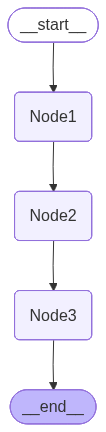

In [29]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [30]:
input=AgentState({"name":"Ishan","age":20,"skills":["Web dev","DSA","AI"],"final":""})
result=app.invoke(input)
print(result["final"])


Hi Ishan.  You are  20 years old.  Your skills are ['Web dev', 'DSA', 'AI'] 
